# 🎬 Bollywood Box Office Analysis & Success Predictor

## Project Overview
This project analyzes 149 Bollywood movies to identify key factors 
that determine box office success and predict whether a movie will 
be a Hit or Flop.

## Tools Used
Python | Pandas | Matplotlib | Seaborn | Scikit-learn

## Key Questions Answered
1. What percentage of Bollywood movies are hits vs flops?
2. Does higher budget guarantee success?
3. Which genres are most profitable?
4. Does social media predict box office success?
5. Can we build a model to predict Hit or Flop?

## Dataset
149 Bollywood movies with budget, box office collection, 
genre and YouTube engagement metrics

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load the dataset
df = pd.read_csv(r'C:\#Raashi\Job Applications\projects for resume\bollywood.csv')

# First look at our data
print(df.shape)
print(df.columns)
df.head()

C:\Users\Harshita\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


(149, 10)
Index(['SlNo', 'Release Date', 'MovieName', 'ReleaseTime', 'Genre', 'Budget',
       'BoxOfficeCollection', 'YoutubeViews', 'YoutubeLikes',
       'YoutubeDislikes'],
      dtype='object')


,SlNo,Release Date,MovieName,ReleaseTime,Genre,Budget,BoxOfficeCollection,YoutubeViews,YoutubeLikes,YoutubeDislikes
0,1,18-Apr-14,2 States,LW,Romance,36,104.00,8576361,26622,2527
1,2,4-Jan-13,Table No. 21,N,Thriller,10,12.00,1087320,1129,137
2,3,18-Jul-14,Amit Sahni Ki List,N,Comedy,10,4.00,572336,586,54
3,4,4-Jan-13,Rajdhani Express,N,Drama,7,0.35,42626,86,19
4,5,4-Jul-14,Bobby Jasoos,N,Comedy,18,10.80,3113427,4512,1224


In [2]:
# Understanding the data
print(df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

(149, 10)

Column names:
['SlNo', 'Release Date', 'MovieName', 'ReleaseTime', 'Genre', 'Budget', 'BoxOfficeCollection', 'YoutubeViews', 'YoutubeLikes', 'YoutubeDislikes']

Data types:
SlNo                     int64
Release Date            object
MovieName               object
ReleaseTime             object
Genre                   object
Budget                   int64
BoxOfficeCollection    float64
YoutubeViews             int64
YoutubeLikes             int64
YoutubeDislikes          int64
dtype: object

Missing values:
SlNo                   0
Release Date           0
MovieName              0
ReleaseTime            0
Genre                  0
Budget                 0
BoxOfficeCollection    0
YoutubeViews           0
YoutubeLikes           0
YoutubeDislikes        0
dtype: int64


In [3]:
# Let's clean and prepare our data
# Extract year from Release Date
df['Year'] = pd.to_datetime(df['Release Date'], errors='coerce').dt.year

### Converted the release date column to datetime format and extracted the year, using errors='coerce' to handle any inconsistent date formats

# Create a profit column
df['Profit'] = df['BoxOfficeCollection'] - df['Budget']

# Create hit or flop column
df['HitOrFlop'] = df['Profit'].apply(lambda x: 'Hit' if x > 0 else 'Flop')

### Used "apply" with a lambda function to categorize each movie as Hit or Flop based on whether its profit was positive or negative

# Check our new columns
df[['MovieName', 'Budget', 'BoxOfficeCollection', 'Profit', 'HitOrFlop']].head(10)

,MovieName,Budget,BoxOfficeCollection,Profit,HitOrFlop
0,2 States,36,104.00,68.00,Hit
1,Table No. 21,10,12.00,2.00,Hit
2,Amit Sahni Ki List,10,4.00,-6.00,Flop
3,Rajdhani Express,7,0.35,-6.65,Flop
4,Bobby Jasoos,18,10.80,-7.20,Flop
5,Citylights,7,35.00,28.00,Hit
6,Daawat-E-Ishq,30,24.60,-5.40,Flop
7,Matru Ki Bijlee Ka Mandola,33,40.00,7.00,Hit
8,Dedh Ishqiya,31,27.00,-4.00,Flop
9,Gangoobai,2,0.01,-1.99,Flop


In [4]:
# How many hits vs flops?
print("Hit vs Flop count:")
print(df['HitOrFlop'].value_counts())

print("\nAverage budget of hits vs flops:")
print(df.groupby('HitOrFlop')['Budget'].mean())

print("\nAverage box office collection of hits vs flops:")
print(df.groupby('HitOrFlop')['BoxOfficeCollection'].mean())

# print("\nMost profitable movie:")
# print(df.loc[df['Profit'].idxmax(), ['MovieName', 'Profit']])

# print("\nBiggest flop:")
# print(df.loc[df['Profit'].idxmin(), ['MovieName', 'Profit']])

Hit vs Flop count:
Hit     83
Flop    66
Name: HitOrFlop, dtype: int64

Average budget of hits vs flops:
HitOrFlop
Flop    29.015152
Hit     29.783133
Name: Budget, dtype: float64

Average box office collection of hits vs flops:
HitOrFlop
Flop    17.773485
Hit     85.799639
Name: BoxOfficeCollection, dtype: float64


print("\nMost profitable movie:")
print(df.loc[df['Profit'].idxmax(), ['MovieName', 'Profit']])

print("\nBiggest flop:")
print(df.loc[df['Profit'].idxmin(), ['MovieName', 'Profit']])



using the above snippet of code will give below result

Most profitable movie:
MovieName       PK
Profit       650.0
Name: 89, dtype: object

Biggest flop:
MovieName    Zanjeer
Profit         -56.8
Name: 130, dtype: object

In [5]:
# Easiest way to find most profitable movie
df.sort_values('Profit', ascending=False)[['MovieName', 'Profit']].head(5)

,MovieName,Profit
89,PK,650.0
115,Chennai Express,320.0
43,Kick,277.0
132,Grand Masti,263.0
26,Happy New Year,258.0


This also simultaneously shows the top 5 blockbuster movies. hence, it is cleaner and more practical used by most analysts.

In [6]:
# Biggest flops
df.sort_values('Profit', ascending=True)[['MovieName', 'Profit']].head(5)

,MovieName,Profit
130,Zanjeer,-56.80
96,Besharam,-50.00
91,Action Jackson,-32.55
148,Kochadaiiyaan,-30.00
102,Kaanchi,-27.00


Sorted the dataframe by profit in descending and ascending order to identify the top performing and worst performing movies respectively

In [7]:
# # Visualization 1 - Hit vs Flop pie chart
# plt.figure(figsize=(8,6))
# df['HitOrFlop'].value_counts().plot(kind='pie', 
#                                      autopct='%1.1f%%',
#                                      colors=['green', 'red'])
# plt.title('Bollywood Movies - Hit vs Flop Ratio')
# plt.ylabel('')
# plt.show()

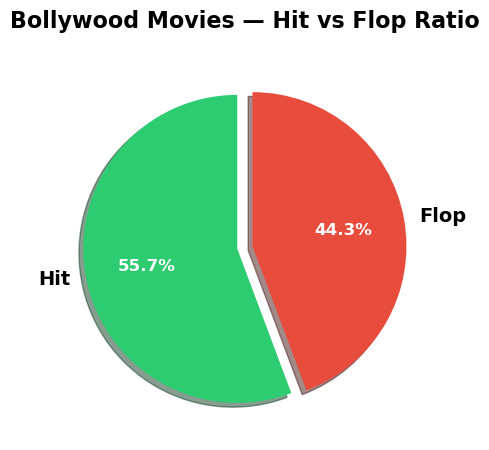

In [8]:
plt.figure(figsize=(5,5))
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.05)

wedges, texts, autotexts = plt.pie(
    df['HitOrFlop'].value_counts(),
    labels=['Hit', 'Flop'],
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    shadow=True,
    startangle=90
)

# Make text bigger and bolder
for text in texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title('Bollywood Movies — Hit vs Flop Ratio', 
          fontsize=16, 
          fontweight='bold', 
          pad=20)

plt.show()

## Understanding the Pie Chart Code

### Hex Color Codes
Colors in matplotlib can be written as hex codes - alphanumeric codes that represent exact colors.
- `#2ecc71` = green
- `#e74c3c` = red

**Where to find hex codes:**
- Google "color picker"
- colorhunt.co
- coolors.co

### autopct (Automatic Percentage)
- Full form: **Automatic Percentage**
- Automatically calculates and displays percentage on each slice
- `'%1.1f%%'` means show one decimal place e.g. "65.3%"

### explode
- Slightly separates slices from the center
- Value of `0.05` creates a small professional-looking gap
- Higher value = bigger separation

### startangle
- Rotates where the first slice begins
- `startangle=90` means the first slice starts from the top

### fontweight
- `'bold'` makes text bold
- `'normal'` keeps text at default weight
- Can be removed entirely for default styling

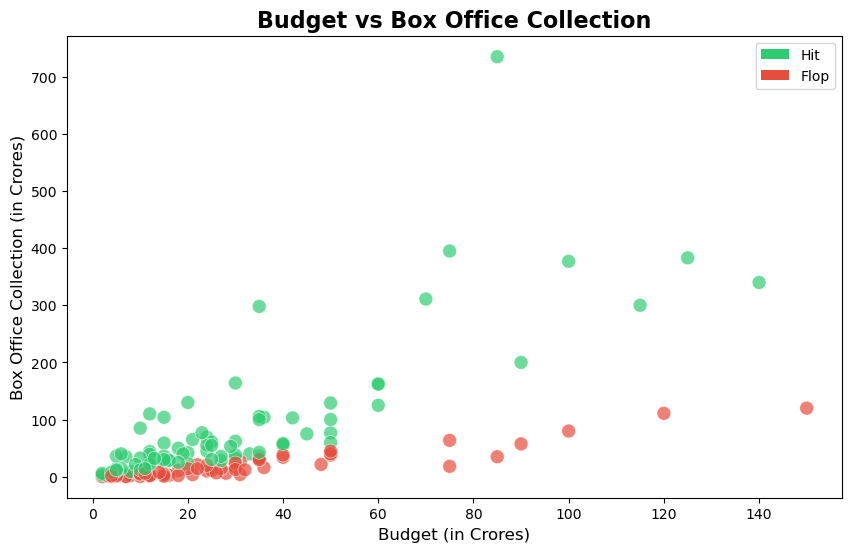

In [9]:
plt.figure(figsize=(10,6))

colors = df['HitOrFlop'].map({'Hit': '#2ecc71', 'Flop': '#e74c3c'})

plt.scatter(df['Budget'], 
            df['BoxOfficeCollection'],
            c=colors,
            alpha=0.7,
            edgecolors='white',
            linewidth=0.5,
            s=100)

plt.title('Budget vs Box Office Collection', fontsize=16, fontweight='bold')
plt.xlabel('Budget (in Crores)', fontsize=12)
plt.ylabel('Box Office Collection (in Crores)', fontsize=12)

# Add legend
from matplotlib.patches import Patch

# Since the scatter plot colors were mapped manually, I used matplotlib.patches to create custom legend elements representing Hit and Flop categories.

legend_elements = [Patch(facecolor='#2ecc71', label='Hit'),
                   Patch(facecolor='#e74c3c', label='Flop')]
plt.legend(handles=legend_elements)

plt.show()

## Insight 2 — Budget vs Box Office Collection

This scatter plot shows the relationship between a movie's budget and its box office earnings.

**Key findings:**
- Higher budget does NOT always guarantee success — several high budget movies flopped
- The biggest hit (PK) had a moderate budget but massive collection (it's that one green dot sitting very high up (around 700+ on the y-axis))
So you found this insight from two places: The sorted data — PK had the highest profit and The scatter plot — visually shows it earned massively relative to its budget

- Most flops cluster near the bottom regardless of budget
- Low budget movies can still be profitable hits

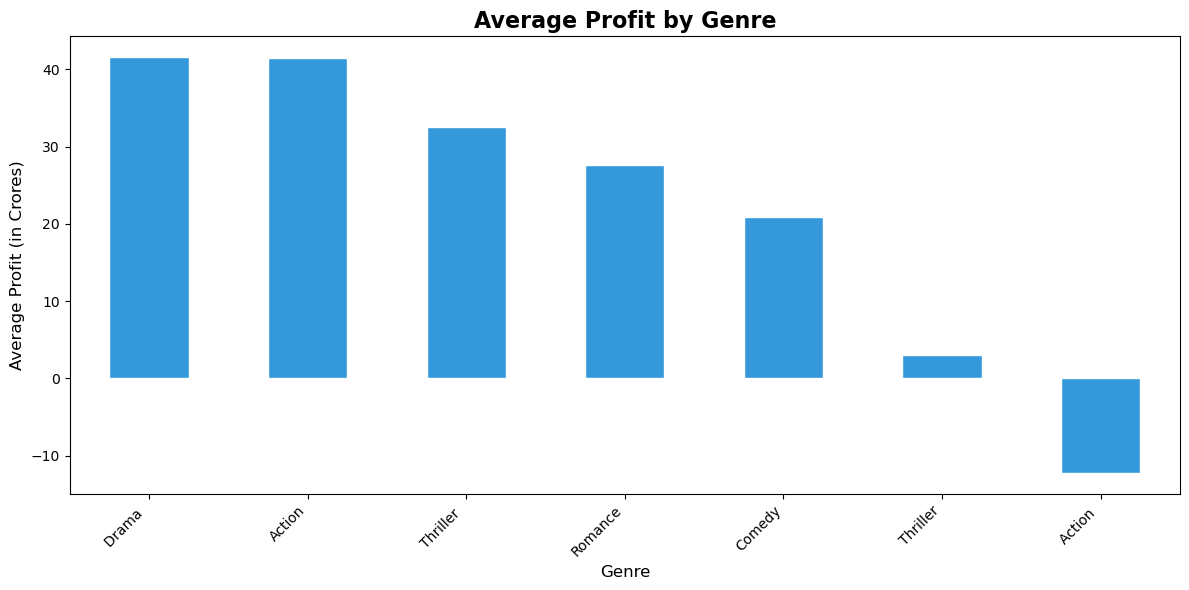

In [10]:
genre_analysis = df.groupby('Genre')['Profit'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
genre_analysis.plot(kind='bar', 
                   color='#3498db',
                   edgecolor='white')

plt.title('Average Profit by Genre', fontsize=16, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Average Profit (in Crores)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Insight 3 — Average Profit by Genre

**Key findings:**
- Drama and Action are the most profitable genres on average
- Thriller and Romance also perform well consistently
- Comedy sits in the middle — safe but not spectacular
- The dataset contains some inconsistent genre labeling 
  (e.g. duplicate Action entries) which affects analysis accuracy
- Investors should focus on Drama and Action for better returns

I noticed inconsistent genre labeling during EDA, so I standardized the text by stripping whitespace and normalizing capitalization before analysis

In [11]:
# Check all unique genres first
print(df['Genre'].unique())

['Romance' 'Thriller ' 'Comedy' ' Drama ' 'Action ' 'Action' 'Thriller']


In [12]:
# Fix inconsistent genre labels
df['Genre'] = df['Genre'].str.strip()  # Remove extra spaces
df['Genre'] = df['Genre'].str.title()  # Standardize capitalization

# Check again
print(df['Genre'].unique())

['Romance' 'Thriller' 'Comedy' 'Drama' 'Action']


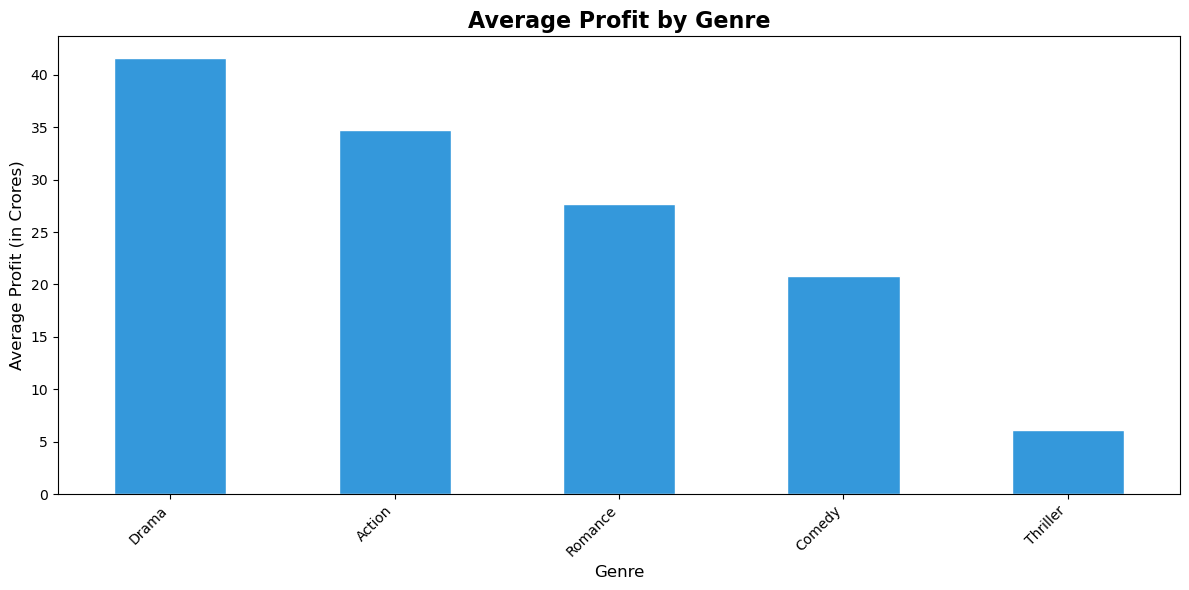

In [13]:
genre_analysis = df.groupby('Genre')['Profit'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
genre_analysis.plot(kind='bar', 
                   color='#3498db',
                   edgecolor='white')

plt.title('Average Profit by Genre', fontsize=16, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Average Profit (in Crores)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Insight 3 — Average Profit by Genre

**Data cleaning applied:**
- Stripped whitespace using str.strip()
- Standardized capitalization using str.title()
- This reduced duplicate genre entries and improved accuracy

**Key findings:**
- Drama is the most profitable genre on average
- Action and Romance follow closely behind
- All genres show positive average profit
- Thriller is least profitable but still viable

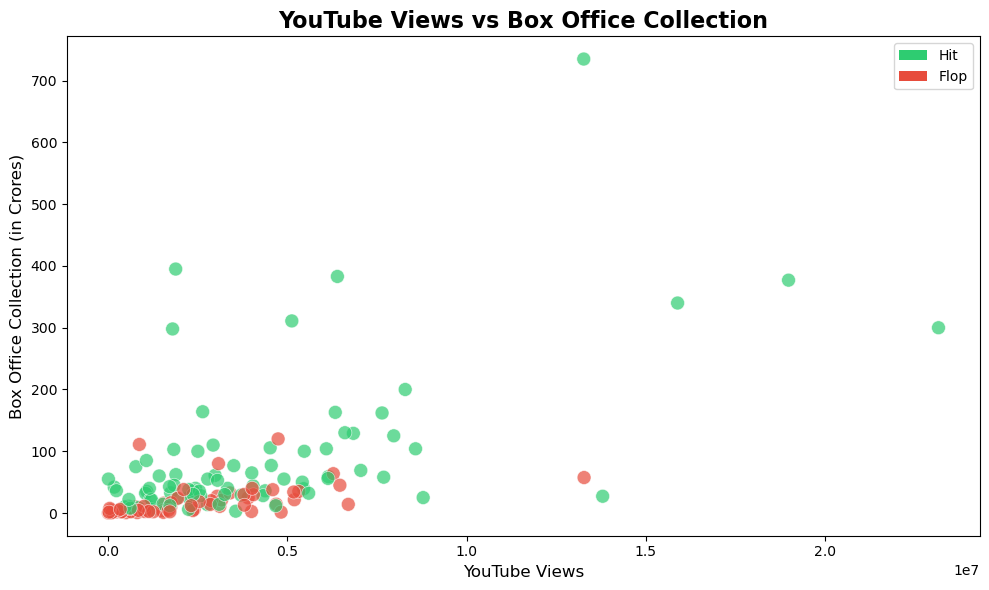

In [14]:
plt.figure(figsize=(10,6))

colors = df['HitOrFlop'].map({'Hit': '#2ecc71', 'Flop': '#e74c3c'})

plt.scatter(df['YoutubeViews'], 
            df['BoxOfficeCollection'],
            c=colors,
            alpha=0.7,
            edgecolors='white',
            linewidth=0.5,
            s=100)

plt.title('YouTube Views vs Box Office Collection', fontsize=16, fontweight='bold')
plt.xlabel('YouTube Views', fontsize=12)
plt.ylabel('Box Office Collection (in Crores)', fontsize=12)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Hit'),
                   Patch(facecolor='#e74c3c', label='Flop')]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

## Insight 4 — YouTube Views vs Box Office Collection

**Key findings:**
- Higher YouTube views generally correlates with higher box office collection
- Social media buzz is a strong but not guaranteed predictor of success
- Some movies with very high YouTube views still flopped — 
  suggesting content quality matters more than just buzz
- PK stands out as the ultimate outlier — highest collection 
  and strong YouTube presence

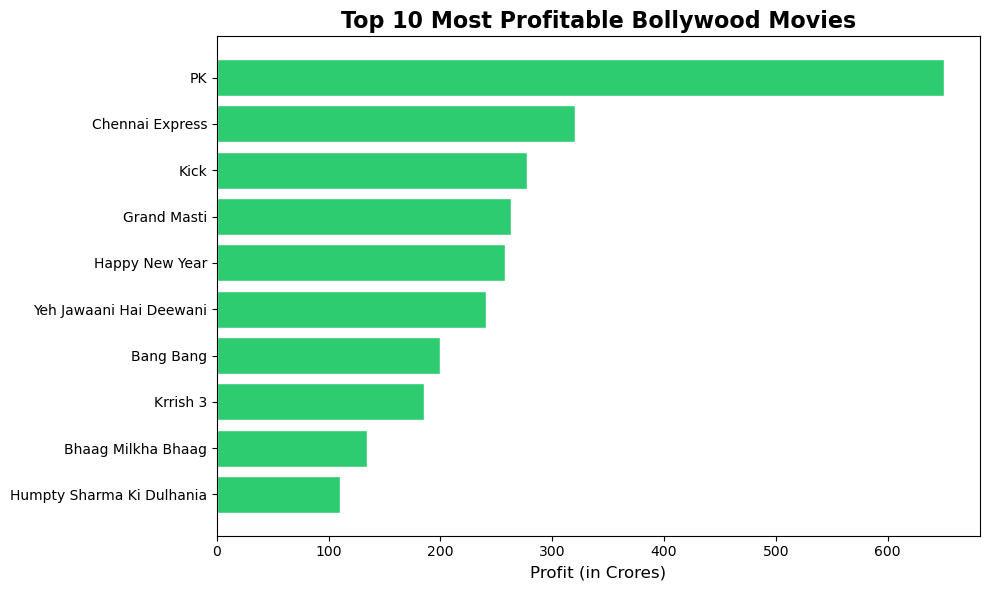

In [15]:
top10 = df.nlargest(10, 'Profit')[['MovieName', 'Profit']]

plt.figure(figsize=(10,6))
plt.barh(top10['MovieName'], 
         top10['Profit'],
         color='#2ecc71',
         edgecolor='white')

plt.title('Top 10 Most Profitable Bollywood Movies', 
          fontsize=16, fontweight='bold')
plt.xlabel('Profit (in Crores)', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Insight 5 — Top 10 Most Profitable Bollywood Movies

**Key findings:**
- PK is the undisputed king with 650 crores profit
- Chennai Express and Kick follow with 300+ crores
- Drama and Action dominate the top 10 list
- Bhaag Milkha Bhaag shows biographical films can be highly profitable

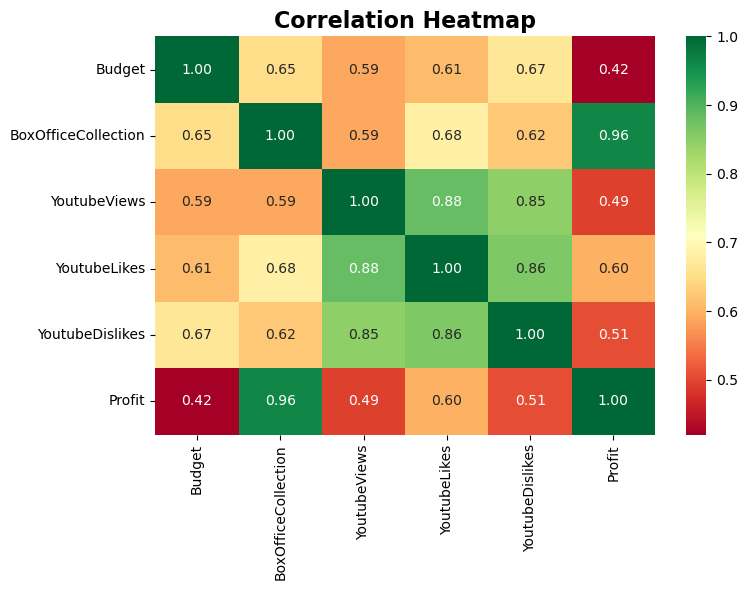

In [16]:
import seaborn as sns

plt.figure(figsize=(8,6))
correlation = df[['Budget', 'BoxOfficeCollection', 
                  'YoutubeViews', 'YoutubeLikes', 
                  'YoutubeDislikes', 'Profit']].corr()

sns.heatmap(correlation, 
            annot=True, 
            cmap='RdYlGn',
            fmt='.2f')

plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Insight 6 — Correlation Heatmap

**Key findings:**
- Box Office Collection and Profit are strongly correlated (0.96)
- YouTube Likes strongly correlate with Box Office Collection (0.68)
- Budget has the weakest correlation with Profit (0.42)
- Social media engagement metrics are highly correlated with each other

**Conclusion:**
Invest in social media marketing over bigger budgets for better returns.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Prepare features
X = df[['Budget', 'YoutubeViews', 'YoutubeLikes', 'YoutubeDislikes']]
y = df['HitOrFlop'].map({'Hit': 1, 'Flop': 0})

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# Test the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['Flop', 'Hit']))

Model Accuracy: 63.33%

Detailed Report:
              precision    recall  f1-score   support

        Flop       0.29      0.25      0.27         8
         Hit       0.74      0.77      0.76        22

    accuracy                           0.63        30
   macro avg       0.51      0.51      0.51        30
weighted avg       0.62      0.63      0.63        30



63% accuracy is actually a decent start for a small dataset of only 149 rows! 🎉
But let's improve it. We'll try a Random Forest model which usually performs better

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Test
rf_pred = rf_model.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, rf_pred, target_names=['Flop', 'Hit']))

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

Random Forest Accuracy: 66.67%

Detailed Report:
              precision    recall  f1-score   support

        Flop       0.42      0.62      0.50         8
         Hit       0.83      0.68      0.75        22

    accuracy                           0.67        30
   macro avg       0.62      0.65      0.62        30
weighted avg       0.72      0.67      0.68        30


Feature Importance:
           Feature  Importance
2     YoutubeLikes    0.286424
1     YoutubeViews    0.265935
3  YoutubeDislikes    0.226586
0           Budget    0.221054


## Machine Learning — Hit or Flop Prediction Model

**Models tested:**
- Logistic Regression: 63.33% accuracy
- Random Forest: 66.67% accuracy

**Best model: Random Forest Classifier**

**Most important features for predicting success:**
1. YouTube Likes (28.6%) — most powerful predictor
2. YouTube Views (26.6%)
3. YouTube Dislikes (22.7%)
4. Budget (22.1%)

**Key insight:**
Social media engagement, especially YouTube Likes, 
is a stronger predictor of box office success than budget alone.

In [19]:
# Test the model with a new movie
new_movie = pd.DataFrame({
    'Budget': [60],
    'YoutubeViews': [8000000],
    'YoutubeLikes': [500000],
    'YoutubeDislikes': [20000]
})

# Scale the input
new_movie_scaled = scaler.transform(new_movie)

# Predict
prediction = rf_model.predict(new_movie_scaled)
probability = rf_model.predict_proba(new_movie_scaled)

print(f"Prediction: {'Hit' if prediction[0] == 1 else 'Flop'}")
print(f"Probability of Hit: {probability[0][1]:.2%}")
print(f"Probability of Flop: {probability[0][0]:.2%}")

Prediction: Hit
Probability of Hit: 97.00%
Probability of Flop: 3.00%


## I built an interactive prediction tool where users can input a movie's budget and YouTube metrics to get a Hit or Flop prediction with probability scores

In [20]:
def predict_movie_success():
    print("🎬 Bollywood Movie Hit or Flop Predictor")
    print("=" * 40)
    
    try:
        budget = float(input("Enter Budget (in Crores): "))
        youtube_views = float(input("Enter YouTube Views: "))
        youtube_likes = float(input("Enter YouTube Likes: "))
        youtube_dislikes = float(input("Enter YouTube Dislikes: "))
        
        new_movie = pd.DataFrame({
            'Budget': [budget],
            'YoutubeViews': [youtube_views],
            'YoutubeLikes': [youtube_likes],
            'YoutubeDislikes': [youtube_dislikes]
        })
        
        new_movie_scaled = scaler.transform(new_movie)
        prediction = rf_model.predict(new_movie_scaled)
        probability = rf_model.predict_proba(new_movie_scaled)
        
        print("\n" + "=" * 40)
        print(f"🎯 Prediction: {'🟢 HIT!' if prediction[0] == 1 else '🔴 FLOP!'}")
        print(f"✅ Probability of Hit: {probability[0][1]:.2%}")
        print(f"❌ Probability of Flop: {probability[0][0]:.2%}")
        
        if probability[0][1] >= 0.75:
            print("\n💡 Strong Hit potential — great social media engagement!")
        elif probability[0][1] >= 0.5:
            print("\n💡 Borderline Hit — consider boosting YouTube marketing!")
        else:
            print("\n💡 Flop risk is high — social media engagement needs work!")
            
    except ValueError:
        print("Please enter valid numbers!")

# Run the predictor
predict_movie_success()

🎬 Bollywood Movie Hit or Flop Predictor
Enter Budget (in Crores): 150
Enter YouTube Views: 500000
Enter YouTube Likes: 10000
Enter YouTube Dislikes: 8000

🎯 Prediction: 🔴 FLOP!
✅ Probability of Hit: 43.00%
❌ Probability of Flop: 57.00%

💡 Flop risk is high — social media engagement needs work!
